In [1]:
%load_ext autoreload
%autoreload 2
%env CUPY_ACCELERATORS=cutensor,cub
%matplotlib inline

import tensorly as tl
tl.set_backend('cupy')
tl.tenalg.set_backend('einsum')
tl.plugins.use_opt_einsum()
print(f'TensorLy backend: {tl.get_backend()}')

env: CUPY_ACCELERATORS=cutensor,cub
TensorLy backend: cupy


In [2]:
from moabb.datasets import BI2012
from moabb.paradigms import P300

dataset = BI2012()
paradigm = P300(resample=48)
X, y, meta = paradigm.get_data(dataset, subjects=[1])
X = tl.tensor(X)

NOTE: pick_types() is a legacy function. New code should use inst.pick(...).


/data/leuven/352/vsc35289/miniconda3/envs/bttda-cuda/lib/python3.11/site-packages/moabb/datasets/preprocessing.py:278: UserWarning: warnEpochs <Epochs | 768 events (all good), 0 – 1 s (baseline off), ~12.1 MiB, data loaded,
 'Target': 128
 'NonTarget': 640>
  warn(f"warnEpochs {epochs}")


The line_profiler extension is already loaded. To reload it, use:
  %reload_ext line_profiler


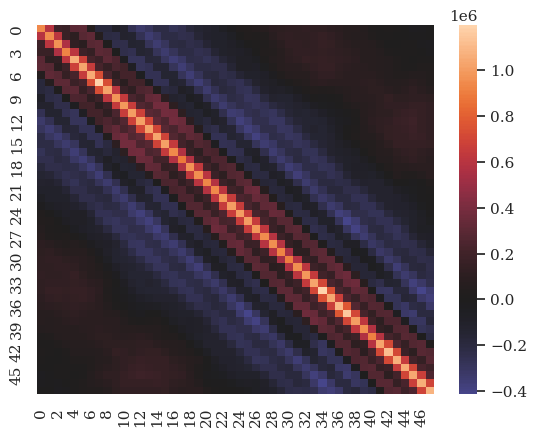

Timer unit: 1e-09 s

Total time: 0.00253057 s
File: /vsc-hard-mounts/leuven-data/352/vsc35289/hoda-bci/src/hoda/cov.py
Function: mode_scatter at line 17

Line #      Hits         Time  Per Hit   % Time  Line Contents
    17                                           def mode_scatter(
    18                                               X, k, weights=None, shrinkage=0, toeplitz=None, taper=False, assume_centered=False
    19                                           ):
    20                                               """Calculate the scatter matrix along a given tensor mode"""
    21                                           
    22         1       5877.0   5877.0      0.2      n_samples, *shape = X.shape
    23         1        869.0    869.0      0.0      order = len(shape)
    24         1        390.0    390.0      0.0      n_features = shape[k]
    25                                               # Determine mode scatter
    26         1       4349.0   4349.0      0.2      modes

In [8]:
from hoda.cov import mode_scatter
import seaborn as sns
import matplotlib.pyplot as plt

%load_ext line_profiler

%lprun -f mode_scatter cov, shrinkage = mode_scatter(X, 1, toeplitz=None, shrinkage='lw')
sns.heatmap(tl.to_numpy(cov), center=0)
plt.show()

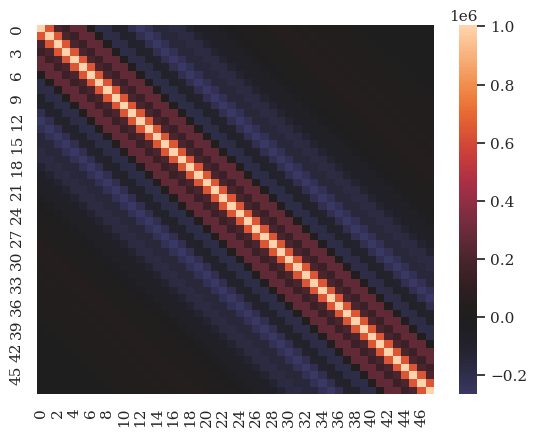

Timer unit: 1e-09 s

Total time: 0.0084131 s
File: /vsc-hard-mounts/leuven-data/352/vsc35289/hoda-bci/src/hoda/cov.py
Function: mode_scatter at line 17

Line #      Hits         Time  Per Hit   % Time  Line Contents
    17                                           def mode_scatter(
    18                                               X, k, weights=None, shrinkage=0, toeplitz=None, taper=False, assume_centered=False
    19                                           ):
    20                                               """Calculate the scatter matrix along a given tensor mode"""
    21                                           
    22         1       5852.0   5852.0      0.1      n_samples, *shape = X.shape
    23         1        840.0    840.0      0.0      order = len(shape)
    24         1        385.0    385.0      0.0      n_features = shape[k]
    25                                               # Determine mode scatter
    26         1       4273.0   4273.0      0.1      modes 

In [9]:
%lprun -f mode_scatter cov, shrinkage = mode_scatter(X, 1, toeplitz=(1,), shrinkage='lw')

sns.heatmap(tl.to_numpy(cov), center=0)
plt.show()